In [12]:
import cv2
import numpy as np
import os

In [13]:
image = cv2.imread("shapes.png")

if image is None:
    print("Image not found!")
else:
    print("Image loaded successfully.")

Image loaded successfully.


In [14]:
# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2.imwrite("gray.png", gray)

True

In [15]:
# Apply Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

cv2.imwrite("threshold.png", thresh)

True

In [16]:
# Detect Contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Total Contours:", len(contours))

Total Contours: 31


In [17]:
# Draw All Contours
contour_image = image.copy()

cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)
cv2.imwrite("all_contours.png", contour_image)

True

In [18]:
# Area, Perimeter, Bounding Rectangle, and Shape Detection
result = image.copy()

for contour in contours:
    area = cv2.contourArea(contour)

    if area < 100:
        continue

    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)

    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
    corners = len(approx)

    if corners == 3:
        shape = "Triangle"
    elif corners == 4:
        aspect_ratio = w / float(h)
        if 0.95 <= aspect_ratio <= 1.05:
            shape = "Square"
        else:
            shape = "Rectangle"
    elif corners > 4:
        circularity = (4 * np.pi * area) / (perimeter * perimeter)
        if circularity > 0.80:
            shape = "Circle"
        else:
            shape = "Polygon"
    else:
        shape = "Unknown"

    cv2.putText(result,
                shape,
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 0, 255),
                2)

    print(f"{shape} | Area = {area:.2f} | Perimeter = {perimeter:.2f}")

cv2.imwrite("shape_detection.png", result)

Rectangle | Area = 11099.50 | Perimeter = 445.41
Square | Area = 5625.00 | Perimeter = 300.00
Triangle | Area = 2579.50 | Perimeter = 242.89
Circle | Area = 4444.50 | Perimeter = 249.04


True

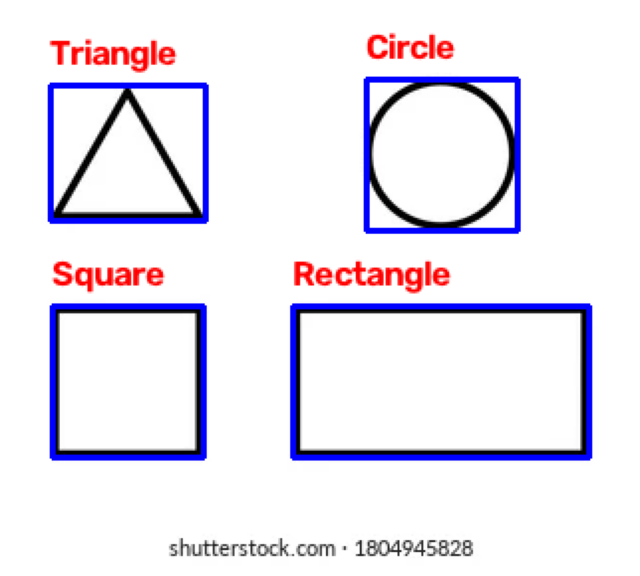

In [19]:
# Display Results
from matplotlib import pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()